# OghmaNano Bragg grating (FDTD) — 正向 I_new + Emission TMM 对齐

Oghma v8.1 FDTD 项目 [`01_hello_bragg_grating`](../../oghma_projects/bragg_grating/01_hello_bragg_grating)：
用 [`00_software_alignment_skills.md`](00_software_alignment_skills.md) 正向构造 `I_new(λ)` 驱动 **emission TMM**（hs 偶极子 @ `z_source`，`u=0`），预测传递与耦合输出谱。

本 notebook 处理 detector0 混源+反射问题，并用 **Case A / B / C** 三条路径（emission 传递比、emission 耦合谱、被动 T 包络）验证互易性。

**运行前提**（[README.md](../../../../README.md)）：`build/simulation.so`；venv + `LD_LIBRARY_PATH`。


In [1]:
import numpy as np

from oghma_runtime import bootstrap_tmm_session

REPO, BUILD, TMM_DIR = bootstrap_tmm_session()
import simulation

from oghma_bragg import (
    bragg_fdtd_stack_labels,
    bragg_fdtd_stack_thicknesses_um,
    build_bragg_fdtd_stack,
    compute_bragg_emission_case_bc_spectra,
    compute_bragg_emission_transfer,
    compute_bragg_lam_e_norm,
    compute_bragg_reflection_ahead_of_z,
    parse_bragg_grating_geometry,
    plot_bragg_fdtd_stack_section,
)
from oghma_core import compare_metrics, fdtd_input_combine_power
from oghma_fdtd_alignment import (
    display_alignment_reports,
    evaluate_case,
    load_fdtd_alignment_bundle,
    plot_case_summary_grid,
    s_in_times_intensity,
)
from oghma_fdtd_source import predict_fdtd_output_spectrum_incoherent

bundle = load_fdtd_alignment_bundle(
    REPO,
    "oghma_projects/bragg_grating/01_hello_bragg_grating",
    parse_bragg_grating_geometry,
)
MASK_BRAGG = (bundle.wl_um >= 0.43) & (bundle.wl_um <= 0.72)
MASK_PASSBAND = (~MASK_BRAGG) | (bundle.s_out > 0.3 * np.max(bundle.s_out))

print(f"BUILD={BUILD}")
print(f"periods={bundle.geom.n_periods}, Λ={bundle.geom.period_um * 1e3:.1f} nm")
print(f"z_source={bundle.layout.z_source_um * 1e3:.0f} nm, z_det_in={bundle.layout.z_detector_in_um * 1e3:.0f} nm")
print(f"λ: {bundle.wl_um[0]*1e3:.0f}–{bundle.wl_um[-1]*1e3:.0f} nm ({len(bundle.wl_um)} pts)")
print(f"FDTD source: {bundle.fdtd_src.waveform}, Ey={bundle.fdtd_src.excite_ey}")
print(f"emission dipole: orient=hs, u=0, z={bundle.layout.z_source_um * 1e3:.0f} nm")


BUILD=/home/like/repos/simulation/build
materials: /mnt/c/Users/like/oghma_local/materials
periods=30, Λ=209.0 nm
z_source=882 nm, z_det_in=1739 nm
λ: 205–1195 nm (100 pts)
FDTD source: gaus_sin, Ey=True
emission dipole: orient=hs, u=0, z=882 nm


## §1 FDTD 膜系与 emission 偶极子

膜系同被动 notebook；emission 偶极子 @ `z_source`，Ey → `hs`，`u=0`（1D 法向）。

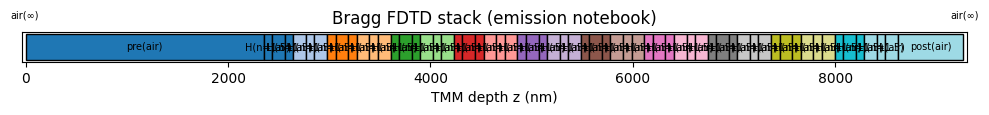

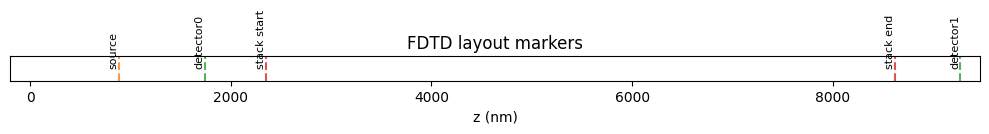

emission dipole: orient=hs, u=0, z=882 nm


In [ ]:
layers_demo = build_bragg_fdtd_stack(
    bundle.geom, bundle.layout, 500.0, simulation
)
labels = bragg_fdtd_stack_labels(bundle.geom, bundle.layout)
thicknesses_nm = bragg_fdtd_stack_thicknesses_um(bundle.geom, bundle.layout)
plot_bragg_fdtd_stack_section(
    bundle.geom,
    bundle.layout,
    simulation,
)
print(f"emission dipole: orient=hs, u=0, z={bundle.layout.z_source_um * 1e3:.0f} nm")


## §2 等效光源(消除时间项)
预期结果 : `S_in = I_new × G_in`  
TODO : 分析原因


In [3]:
import numpy as np
r_det = compute_bragg_reflection_ahead_of_z(
    bundle.layout.z_detector_in_um * 1e3,
    bundle.geom,
    bundle.layout,
    bundle.wl_um,
    simulation,
    )
g_in = fdtd_input_combine_power(r_det)
s_pred_det0 = predict_fdtd_output_spectrum_incoherent(bundle.i_new, g_in)
s_in_norm = s_in_times_intensity(bundle)

evaluate_case(
    bundle,
    "§2 I_new vs S_IN×Intensity",
    bundle.i_new,
    s_in_norm,
    mask=MASK_BRAGG,
    mask_label="430,720",
    ylabel="|E|²",
    title="§2: I_new vs S_IN×Intensity",
    tmm_label="I_new",
    baseline_name="S_IN×Int",
)
# evaluate_case(
#     bundle,
#     "§2 I_new×G_in vs S_IN",
#     s_pred_det0,
#     bundle.s_in,
#     mask=MASK_BRAGG,
#     mask_label="430,720",
#     ylabel="|E|²",
#     title="§2: I_new×G_in vs detector0",
#     tmm_label="I_new×G_in",
#     baseline_name="S_IN (det0)",
# )


[FAIL] §2 I_new vs S_IN×Intensity (raw): RMSE=0.2638, max|err|=0.9791, corr=0.7533
  stop-band λ: ours=205.0 nm, baseline=205.0 nm, Δ=0.0 nm
[FAIL] §2 I_new vs S_IN×Intensity (raw) [430,720]: RMSE=0.4799, max|err|=0.9791, corr=0.2393
  stop-band λ: ours=435.0 nm, baseline=565.0 nm, Δ=130.0 nm
[FAIL (envelope)] §2 I_new vs S_IN×Intensity (norm): norm-corr=0.7533, RMSE=0.2638
[FAIL (envelope)] §2 I_new vs S_IN×Intensity norm [430,720]: norm-corr=0.2393, RMSE=0.4799


## §3 Case A — 传递比 T(λ)

$T/|1+r|^2$ = $S_{out}/S_{in}$

In [4]:
import numpy as np
em = compute_bragg_emission_transfer(
    bundle.geom,
    bundle.layout,
    bundle.wl_um,
    simulation,
    z_um=bundle.layout.z_source_um,
    u=0.0,
    orient="hs",
)
T_EM = em["t_trans_ratio_fdtd"]
T_PASSIVE = compute_bragg_lam_e_norm(
    bundle.geom, bundle.layout, bundle.wl_um, simulation
)

evaluate_case(
    bundle,
    "Case A T_em",
    T_EM,
    T_PASSIVE,
    mask=MASK_BRAGG,
    mask_label="430,720",
    ylabel="T/G_in",
    title="Case A: emission T/G_in vs T_passive/G_in",
    tmm_label="T_em",
    baseline_name="T_passive/G_in",
)


[FAIL] Case A T_em (raw): RMSE=0.4509, max|err|=0.6953, corr=0.8019
  stop-band λ: ours=515.0 nm, baseline=505.0 nm, Δ=10.0 nm
[FAIL] Case A T_em (raw) [430,720]: RMSE=0.3107, max|err|=0.6953, corr=0.8491
  stop-band λ: ours=515.0 nm, baseline=505.0 nm, Δ=10.0 nm
[FAIL (envelope)] Case A T_em (norm): norm-corr=0.8019, RMSE=0.3302
[FAIL (envelope)] Case A T_em norm [430,720]: norm-corr=0.8491, RMSE=0.2478


## §4 Case B / C — 耦合输出谱 vs `detector1/lam_E`

**验收基准**：`S_OUT`（FDTD `detector1`）。

- **Case B**：相干 $\mathrm{flux}(E_{bot}^{sum})$，源谱用正向 $I_{new}(\lambda)$
- **Case C**：$T_{passive}(\lambda)\, I_{new}(\lambda)$（[`00_software_alignment_skills.md`](00_software_alignment_skills.md) 非相干输出；不用 $S_{IN}$，因其混入了源与反射）


In [5]:
import numpy as np
case_bc = compute_bragg_emission_case_bc_spectra(
    simulation,
    bundle.geom,
    bundle.layout,
    bundle.wl_um,
    bundle.s_in,
    spectrum=bundle.i_new,
    t_passive=T_PASSIVE,
)
S_PRED_B = case_bc["s_pred_b"]
S_PRED_C = case_bc["s_pred_c"]

for tag, mask in [
    ("full", np.ones_like(bundle.wl_um, dtype=bool)),
    ("Bragg [430,720]", MASK_BRAGG),
    ("passband / far stop", MASK_PASSBAND),
]:
    sb = compare_metrics(S_PRED_B[mask], bundle.s_out[mask], x=bundle.wl_um[mask])
    sc = compare_metrics(S_PRED_C[mask], bundle.s_out[mask], x=bundle.wl_um[mask])
    print(f"[{tag}] B corr={sb['corr']:.4f}  C corr={sc['corr']:.4f}")

evaluate_case(
    bundle,
    "Case B P_bot",
    S_PRED_B,
    bundle.s_out,
    mask=MASK_BRAGG,
    mask_label="430,720",
    ylabel="|E|²",
    title="Case B: coherent flux(E_bot) vs S_OUT",
    tmm_label="flux(E_bot_sum)",
    baseline_name="S_OUT",
)
evaluate_case(
    bundle,
    "Case C T_passive·I_new",
    S_PRED_C,
    bundle.s_out,
    mask=MASK_BRAGG,
    mask_label="430,720",
    ylabel="|E|²",
    title="Case C: T_passive·I_new vs S_OUT",
    tmm_label="T_passive·I_new",
    baseline_name="S_OUT",
)
evaluate_case(
    bundle,
    "Case D emission vs passive",
    S_PRED_B,
    S_PRED_C,
    mask=MASK_BRAGG,
    mask_label="430,720",
    ylabel="|E|²",
    title="Case D: emission vs passive",
    tmm_label="Case B",
    baseline_name="Case C",
)


[full] B corr=0.9790  C corr=0.9863
[Bragg [430,720]] B corr=0.9757  C corr=0.9878
[passband / far stop] B corr=0.9778  C corr=0.9858
[FAIL] Case B P_bot (raw): RMSE=0.2208, max|err|=0.8245, corr=0.9790
  stop-band λ: ours=205.0 nm, baseline=505.0 nm, Δ=300.0 nm
[FAIL] Case B P_bot (raw) [430,720]: RMSE=0.3745, max|err|=0.8245, corr=0.9757
  stop-band λ: ours=505.0 nm, baseline=505.0 nm, Δ=0.0 nm
[PASS (envelope)] Case B P_bot (norm): norm-corr=0.9790, RMSE=0.0555
[PASS (envelope)] Case B P_bot norm [430,720]: norm-corr=0.9757, RMSE=0.0890
[FAIL] Case C T_passive·I_new (raw): RMSE=0.2467, max|err|=0.9068, corr=0.9863
  stop-band λ: ours=205.0 nm, baseline=505.0 nm, Δ=300.0 nm
[FAIL] Case C T_passive·I_new (raw) [430,720]: RMSE=0.4249, max|err|=0.9068, corr=0.9878
  stop-band λ: ours=505.0 nm, baseline=505.0 nm, Δ=0.0 nm
[PASS (envelope)] Case C T_passive·I_new (norm): norm-corr=0.9863, RMSE=0.0462
[PASS (envelope)] Case C T_passive·I_new norm [430,720]: norm-corr=0.9878, RMSE=0.0630
[P

## §6 Case 汇总

汇总 `CASE_SUMMARY`，并同时绘制 raw 与 peak-normalized 对比图。


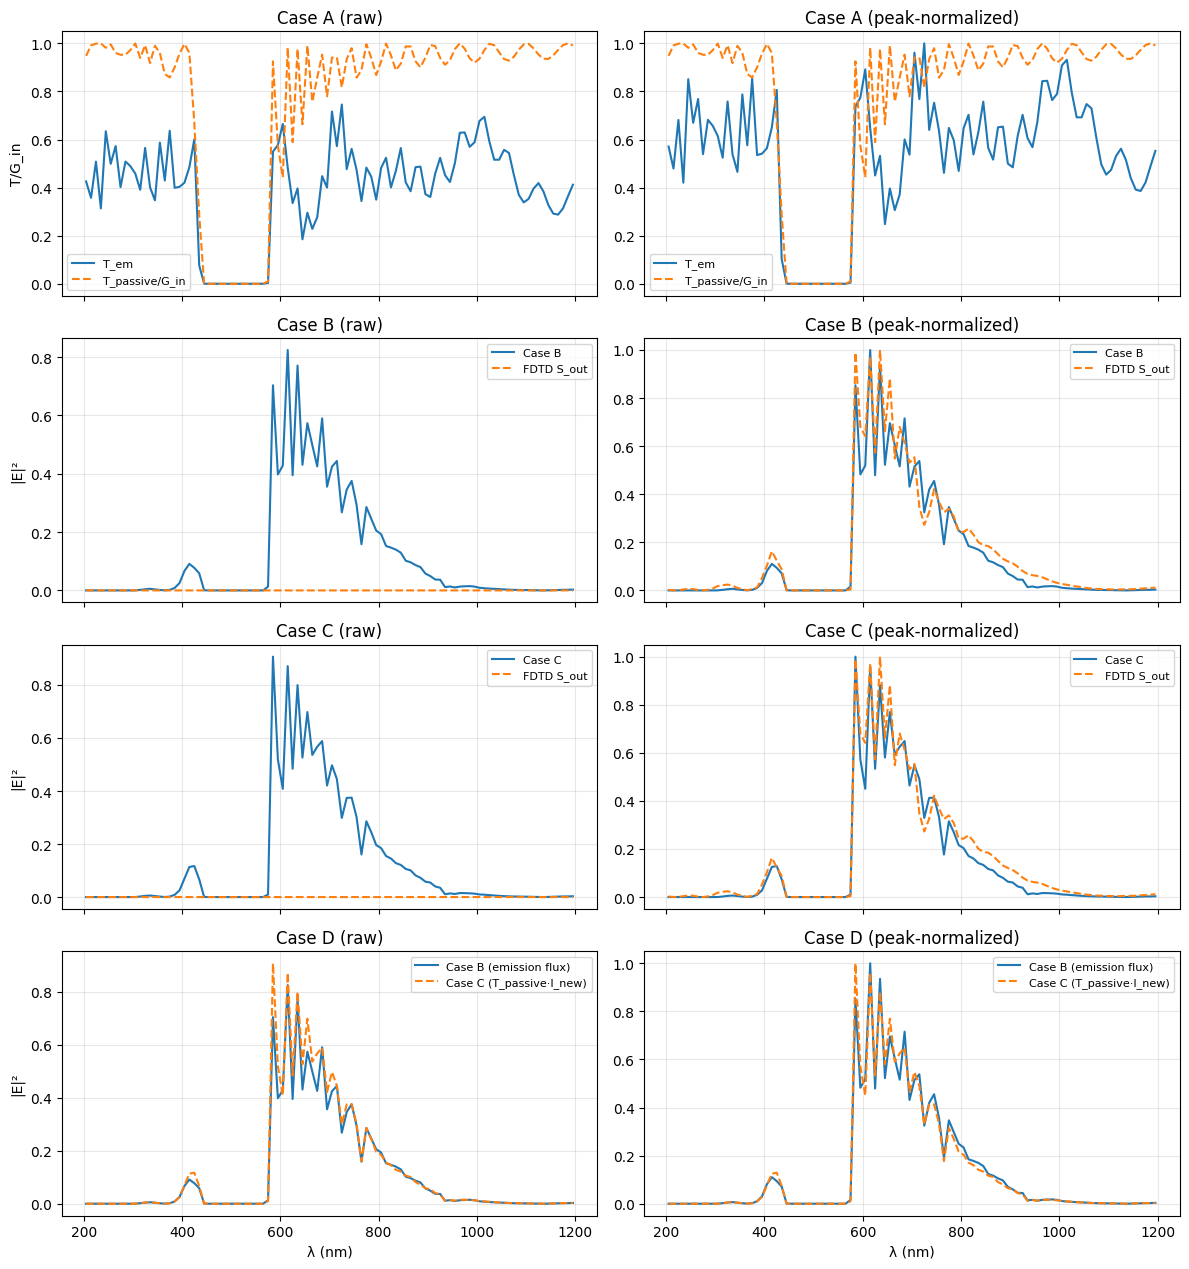

In [6]:
plot_case_summary_grid(
    bundle,
    [
        {
            "title": "Case A",
            "pred": T_EM,
            "baseline": T_PASSIVE,
            "pred_label": "T_em",
            "baseline_label": "T_passive/G_in",
            "ylabel": "T/G_in",
        },
        {
            "title": "Case B",
            "pred": S_PRED_B,
            "baseline": bundle.s_out,
            "pred_label": "Case B",
            "baseline_label": "FDTD S_out",
        },
        {
            "title": "Case C",
            "pred": S_PRED_C,
            "baseline": bundle.s_out,
            "pred_label": "Case C",
            "baseline_label": "FDTD S_out",
        },
        {
            "title": "Case D",
            "pred": S_PRED_B,
            "baseline": S_PRED_C,
            "pred_label": "Case B (emission flux)",
            "baseline_label": "Case C (T_passive·I_new)",
        },
    ],
)


## §7 对齐报告


In [7]:
display_alignment_reports(bundle)

print("\n--- FDTD → TMM 映射要点 ---")
print("1. Case B/C baseline = detector1 lam_E (S_OUT); §2 S_source is provisional")
print("2. FDTD Ey → emission hs dipole, u=0")
print(f"3. dipole z = {bundle.layout.z_source_um * 1e3:.0f} nm; stack = build_bragg_fdtd_stack")
print("4. evaluate_case(bundle, ...): raw + peak-normalized compare/plots")
for k, v in bundle.case_summary.items():
    line = f"   {k}: corr={v['corr']:.4f}, RMSE={v['rmse']:.4f}"
    line += f", norm-corr={v.get('norm_corr', float('nan')):.4f}"
    print(line)
print("5. PML → semi-infinite air; pre/post air from FDTD z geometry")


,corr,rmse,norm_corr,rmse_norm,log_domain
case,,,,,
§2 I_new vs S_IN×Intensity,0.753268,0.263840,0.753268,0.263840,False
Case A T_em,0.801888,0.450927,0.801888,0.330219,False
Case B P_bot,0.978958,0.220805,0.978958,0.055455,False
Case C T_passive·I_new,0.986322,0.246724,0.986322,0.046234,False
Case D emission vs passive,0.992672,0.035654,0.992672,0.028635,False


,case,rmse,mae,max_abs,corr,stop_x_ours,stop_x_baseline,stop_delta_nm,stop_log_rmse,status
0,§2 I_new vs S_IN×Intensity (raw),0.263840,0.142356,0.979106,0.753268,205.0,205.0,0.0,0.726590,FAIL
1,"§2 I_new vs S_IN×Intensity (raw) [430,720]",0.479918,0.407567,0.979106,0.239267,435.0,565.0,130.0,1.942663,FAIL
2,§2 I_new vs S_IN×Intensity (norm),0.263840,0.142356,0.979106,0.753268,205.0,205.0,0.0,0.726590,FAIL (envelope)
3,"§2 I_new vs S_IN×Intensity norm [430,720]",0.479918,0.407567,0.979106,0.239267,435.0,565.0,130.0,1.942663,FAIL (envelope)
4,Case A T_em (raw),0.450927,0.400495,0.695280,0.801888,515.0,505.0,10.0,0.756841,FAIL
5,"Case A T_em (raw) [430,720]",0.310687,0.203831,0.695280,0.849083,515.0,505.0,10.0,0.756841,FAIL
6,Case A T_em (norm),0.330219,0.280974,0.594349,0.801888,515.0,505.0,10.0,0.787610,FAIL (envelope)
7,"Case A T_em norm [430,720]",0.247754,0.159564,0.587527,0.849083,515.0,505.0,10.0,0.791892,FAIL (envelope)
8,Case B P_bot (raw),0.220805,0.112529,0.824500,0.978958,205.0,505.0,300.0,8.745105,FAIL
9,"Case B P_bot (raw) [430,720]",0.374457,0.252918,0.824500,0.975680,505.0,505.0,0.0,3.111881,FAIL



--- FDTD → TMM 映射要点 ---
1. Case B/C baseline = detector1 lam_E (S_OUT); §2 S_source is provisional
2. FDTD Ey → emission hs dipole, u=0
3. dipole z = 882 nm; stack = build_bragg_fdtd_stack
4. evaluate_case(bundle, ...): raw + peak-normalized compare/plots
   §2 I_new vs S_IN×Intensity: corr=0.7533, RMSE=0.2638, norm-corr=0.7533
   Case A T_em: corr=0.8019, RMSE=0.4509, norm-corr=0.8019
   Case B P_bot: corr=0.9790, RMSE=0.2208, norm-corr=0.9790
   Case C T_passive·I_new: corr=0.9863, RMSE=0.2467, norm-corr=0.9863
   Case D emission vs passive: corr=0.9927, RMSE=0.0357, norm-corr=0.9927
5. PML → semi-infinite air; pre/post air from FDTD z geometry


## §8 总结

**Case B/C 以 `S_OUT` 对齐结果为据**（非草稿中的固定 corr 值）。

| Case | 路径 | 公式 | Baseline |
|---|---|---|---|
| **A** | 忽略时间相干效应（如果这个效应存在的话...） | $S_{in} = I_{new} × |1+r|^2$ | `detector0` |
| **B** | emission 相干 flux | $\mathrm{flux}(E_{bot}^{sum})$, 源谱 $I_{new}(\lambda)$ | `detector1` |
| **C** | 被动 TMM | $T_{passive}\cdot I_{new}$ | `detector1` |

Case A 我的预期是包络相同， 这里的 '时间相干性' 应该怎么理解呢?   
Case B/C 均用等效源谱 $I_{new}$。  
Case C 为被动非相干包络，Bragg 窗内 corr 通常与 Case B 同量级。阻带峰位应对齐 ~505 nm。  
detector 能量和 tmm 我怀疑量纲没有对齐，导致只有归一化之后形状才能接近。  
